In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Datasets
We have 2 csv file

In [3]:
costumers = pd.read_csv("Dim_customers.csv")
costumers.head(3)

,customer_id,customer_name,city,age,segment
0,1,Cust_1,Bangalore,67.0,NaN
1,2,Cust_2,Delhi,29.0,Retail
2,3,Cust_3,Chennai,22.0,NaN


In [4]:
costumers.columns = costumers.columns.str.strip()

In [5]:
costumers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25926 entries, 0 to 25925
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer_id    25926 non-null  int64  
 1   customer_name  25926 non-null  object 
 2   city           21613 non-null  object 
 3   age            25411 non-null  float64
 4   segment        19486 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 1012.9+ KB


In [6]:
costumers.describe()

,customer_id,age
count,25926.000000,25411.000000
mean,12963.500000,43.507457
std,7484.335876,14.967854
min,1.000000,18.000000
25%,6482.250000,31.000000
50%,12963.500000,44.000000
75%,19444.750000,56.000000
max,25926.000000,69.000000


In [7]:
costumers.isnull().sum()

customer_id         0
customer_name       0
city             4313
age               515
segment          6440
dtype: int64

In [8]:
costumers.duplicated().sum()

np.int64(0)

In [9]:
costumers.shape

(25926, 5)

In [10]:
costumers.columns

Index(['customer_id', 'customer_name', 'city', 'age', 'segment'], dtype='object')

In [11]:
costumers.dtypes

customer_id        int64
customer_name     object
city              object
age              float64
segment           object
dtype: object

In [12]:
costumers["age"]=costumers ["age"].fillna(costumers["age"].mean())
costumers["city"]=costumers ["city"].fillna("Not Available")
costumers["segment"]=costumers ["segment"].fillna("Not Available")

In [13]:
costumers['age']=costumers["age"].astype("int")

In [14]:
costumers_copy=costumers.copy()

In [15]:
fact_df = pd.read_csv("Fact_transactions.csv")
fact_df.head(3)

,transaction_id,customer_id,product,quantity,price,date,payment_method,discount,rating,remarks
0,1,21225,Phone,4,29260.32,2023-06-14,UPI,0.27,NaN,Average
1,2,6415,Camera,1,21028.22,2023-07-16,Card,0.05,NaN,Bad
2,3,12258,Tablet,6,27976.14,2023-06-05,Card,0.19,5.0,NaN


In [16]:
fact_df.columns = fact_df.columns.str.strip()

In [17]:
fact_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78277 entries, 0 to 78276
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  78277 non-null  int64  
 1   customer_id     78277 non-null  int64  
 2   product         78277 non-null  object 
 3   quantity        70549 non-null  object 
 4   price           78277 non-null  object 
 5   date            78277 non-null  object 
 6   payment_method  58731 non-null  object 
 7   discount        78277 non-null  float64
 8   rating          65165 non-null  float64
 9   remarks         62610 non-null  object 
dtypes: float64(2), int64(2), object(6)
memory usage: 6.0+ MB


In [18]:
fact_df.isnull().sum()

transaction_id        0
customer_id           0
product               0
quantity           7728
price                 0
date                  0
payment_method    19546
discount              0
rating            13112
remarks           15667
dtype: int64

In [19]:
fact_df.describe()

,transaction_id,customer_id,discount,rating
count,78277.000000,78277.000000,78277.000000,65165.000000
mean,38893.918686,12973.745979,0.150061,3.001888
std,22449.390784,7484.714138,0.086675,1.415476
min,1.000000,1.000000,0.000000,1.000000
25%,19454.000000,6491.000000,0.070000,2.000000
50%,38898.000000,12955.000000,0.150000,3.000000
75%,58331.000000,19478.000000,0.230000,4.000000
max,77777.000000,25926.000000,0.300000,5.000000


In [20]:
fact_df.duplicated().sum()

np.int64(495)

In [21]:
fact_df.dtypes

transaction_id      int64
customer_id         int64
product            object
quantity           object
price              object
date               object
payment_method     object
discount          float64
rating            float64
remarks            object
dtype: object

In [22]:
fact_df.isnull().sum()

transaction_id        0
customer_id           0
product               0
quantity           7728
price                 0
date                  0
payment_method    19546
discount              0
rating            13112
remarks           15667
dtype: int64

In [23]:
fact_df

,transaction_id,customer_id,product,quantity,price,date,payment_method,discount,rating,remarks
0,1,21225,Phone,4,29260.32,2023-06-14,UPI,0.27,NaN,Average
1,2,6415,Camera,1,21028.22,2023-07-16,Card,0.05,NaN,Bad
2,3,12258,Tablet,6,27976.14,2023-06-05,Card,0.19,5.0,NaN
3,4,24708,Laptop,5,39365.86,2023-04-20,Card,0.16,NaN,Bad
4,5,25698,Laptop,7,4460.89,2023-03-30,NaN,0.23,2.0,Bad
...,...,...,...,...,...,...,...,...,...,...
78272,35998,20639,Tablet,3,8745.81,2023-05-13,UPI,0.06,NaN,NaN
78273,29046,9187,Tablet,3,23050.66,2023-10-09,Cash,0.23,NaN,Good
78274,70712,14399,Phone,2,11919.91,2023-08-04,UPI,0.18,2.0,Average
78275,57106,17013,Tablet,8,49199.26,2023-04-22,Cash,0.13,4.0,Average


In [24]:
fact_df["price"].max()

'error'

In [25]:
fact_df["quantity"].unique()

array(['4', '1', '6', '5', '7', '2', '3', '9', nan, '8', 'unknown'],
      dtype=object)

In [26]:
fact_df['price'].unique()

array(['29260.32', '21028.22', '27976.14', ..., '14447.74', '32051.5',
       '41721.95'], dtype=object)

In [27]:
'error' in fact_df['price'].values

True

In [28]:
fact_df["price"]= fact_df ["price"].replace("error",0).astype("float64")

In [29]:
fact_df["quantity"]= fact_df ["quantity"].fillna(0)

In [30]:
fact_df['quantity'] = fact_df['quantity'].replace('unknown', 0)

In [31]:
fact_df['quantity']=fact_df["quantity"].astype("int64")

In [32]:
fact_df['price'].dtypes

dtype('float64')

In [33]:
fact_df.shape

(78277, 10)

In [34]:
fact_df["date"] = pd.to_datetime(fact_df["date"],format="mixed")

In [35]:
fact_df.dtypes

transaction_id             int64
customer_id                int64
product                   object
quantity                   int64
price                    float64
date              datetime64[ns]
payment_method            object
discount                 float64
rating                   float64
remarks                   object
dtype: object

In [36]:
fact_df

,transaction_id,customer_id,product,quantity,price,date,payment_method,discount,rating,remarks
0,1,21225,Phone,4,29260.32,2023-06-14,UPI,0.27,NaN,Average
1,2,6415,Camera,1,21028.22,2023-07-16,Card,0.05,NaN,Bad
2,3,12258,Tablet,6,27976.14,2023-06-05,Card,0.19,5.0,NaN
3,4,24708,Laptop,5,39365.86,2023-04-20,Card,0.16,NaN,Bad
4,5,25698,Laptop,7,4460.89,2023-03-30,NaN,0.23,2.0,Bad
...,...,...,...,...,...,...,...,...,...,...
78272,35998,20639,Tablet,3,8745.81,2023-05-13,UPI,0.06,NaN,NaN
78273,29046,9187,Tablet,3,23050.66,2023-10-09,Cash,0.23,NaN,Good
78274,70712,14399,Phone,2,11919.91,2023-08-04,UPI,0.18,2.0,Average
78275,57106,17013,Tablet,8,49199.26,2023-04-22,Cash,0.13,4.0,Average


In [37]:
fact_df.isnull().sum()

transaction_id        0
customer_id           0
product               0
quantity              0
price                 0
date                  0
payment_method    19546
discount              0
rating            13112
remarks           15667
dtype: int64

In [38]:
fact_df['quantity']=fact_df["quantity"].astype("int64")

In [39]:
fact_df.dtypes

transaction_id             int64
customer_id                int64
product                   object
quantity                   int64
price                    float64
date              datetime64[ns]
payment_method            object
discount                 float64
rating                   float64
remarks                   object
dtype: object

In [40]:
fact_df["quantity"].unique()

array([4, 1, 6, 5, 7, 2, 3, 9, 0, 8])

In [41]:
type(fact_df)

pandas.core.frame.DataFrame

In [42]:
fact_df["quantity"]= fact_df ["quantity"].fillna(0)

In [43]:
fact_df.describe()

,transaction_id,customer_id,quantity,price,date,discount,rating
count,78277.000000,78277.000000,78277.000000,78277.000000,78277,78277.000000,65165.000000
mean,38893.918686,12973.745979,4.494769,25488.649654,2023-07-01 18:56:17.819793920,0.150061,3.001888
min,1.000000,1.000000,0.000000,0.000000,2023-01-01 00:00:00,0.000000,1.000000
25%,19454.000000,6491.000000,2.000000,13209.320000,2023-04-02 00:00:00,0.070000,2.000000
50%,38898.000000,12955.000000,4.000000,25492.690000,2023-07-01 00:00:00,0.150000,3.000000
75%,58331.000000,19478.000000,7.000000,37745.590000,2023-09-30 00:00:00,0.230000,4.000000
max,77777.000000,25926.000000,9.000000,49996.560000,2023-12-31 00:00:00,0.300000,5.000000
std,22449.390784,7484.714138,2.876251,14189.740477,NaN,0.086675,1.415476


In [44]:
fact_df

,transaction_id,customer_id,product,quantity,price,date,payment_method,discount,rating,remarks
0,1,21225,Phone,4,29260.32,2023-06-14,UPI,0.27,NaN,Average
1,2,6415,Camera,1,21028.22,2023-07-16,Card,0.05,NaN,Bad
2,3,12258,Tablet,6,27976.14,2023-06-05,Card,0.19,5.0,NaN
3,4,24708,Laptop,5,39365.86,2023-04-20,Card,0.16,NaN,Bad
4,5,25698,Laptop,7,4460.89,2023-03-30,NaN,0.23,2.0,Bad
...,...,...,...,...,...,...,...,...,...,...
78272,35998,20639,Tablet,3,8745.81,2023-05-13,UPI,0.06,NaN,NaN
78273,29046,9187,Tablet,3,23050.66,2023-10-09,Cash,0.23,NaN,Good
78274,70712,14399,Phone,2,11919.91,2023-08-04,UPI,0.18,2.0,Average
78275,57106,17013,Tablet,8,49199.26,2023-04-22,Cash,0.13,4.0,Average


In [45]:
fact_df["price"]=fact_df["price"].fillna("mean")

In [46]:
fact_df.dtypes

transaction_id             int64
customer_id                int64
product                   object
quantity                   int64
price                    float64
date              datetime64[ns]
payment_method            object
discount                 float64
rating                   float64
remarks                   object
dtype: object

In [47]:
fact_df["price"].unique()

array([29260.32, 21028.22, 27976.14, ..., 14447.74, 32051.5 , 41721.95])

In [48]:
fact_df["price"].duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
78272     True
78273     True
78274     True
78275     True
78276     True
Name: price, Length: 78277, dtype: bool

In [49]:
fact_df = fact_df.drop_duplicates()

In [50]:
fact_df.duplicated().sum()

np.int64(0)

In [51]:
fact_df["payment_method"]=fact_df["payment_method"].fillna("Unavailable")

In [52]:
fact_df["remarks"]=fact_df["remarks"].fillna("Not Unavailable")

In [53]:
fact_df["rating"]=fact_df["rating"].fillna(0)

In [54]:
costumers_copy = costumers.copy()

In [55]:
fact_df_copy = fact_df.copy()

In [56]:
costumers_copy.head()

,customer_id,customer_name,city,age,segment
0,1,Cust_1,Bangalore,67,Not Available
1,2,Cust_2,Delhi,29,Retail
2,3,Cust_3,Chennai,22,Not Available
3,4,Cust_4,Delhi,26,Retail
4,5,Cust_5,Delhi,61,SME


In [57]:
fact_df_copy.head()

,transaction_id,customer_id,product,quantity,price,date,payment_method,discount,rating,remarks
0,1,21225,Phone,4,29260.32,2023-06-14,UPI,0.27,0.0,Average
1,2,6415,Camera,1,21028.22,2023-07-16,Card,0.05,0.0,Bad
2,3,12258,Tablet,6,27976.14,2023-06-05,Card,0.19,5.0,Not Unavailable
3,4,24708,Laptop,5,39365.86,2023-04-20,Card,0.16,0.0,Bad
4,5,25698,Laptop,7,4460.89,2023-03-30,Unavailable,0.23,2.0,Bad


In [58]:
fact_df_copy.isnull().sum()

transaction_id    0
customer_id       0
product           0
quantity          0
price             0
date              0
payment_method    0
discount          0
rating            0
remarks           0
dtype: int64

In [88]:
join_2_columns.shape

(77782, 15)

In [59]:
join_2_columns = pd.merge(fact_df_copy,costumers_copy,on="customer_id",how="left")
join_2_columns.head()

,transaction_id,customer_id,product,quantity,price,date,payment_method,discount,rating,remarks,customer_name,city,age,segment
0,1,21225,Phone,4,29260.32,2023-06-14,UPI,0.27,0.0,Average,Cust_21225,Bangalore,31,Retail
1,2,6415,Camera,1,21028.22,2023-07-16,Card,0.05,0.0,Bad,Cust_6415,Not Available,44,Not Available
2,3,12258,Tablet,6,27976.14,2023-06-05,Card,0.19,5.0,Not Unavailable,Cust_12258,Kozhikode,59,Retail
3,4,24708,Laptop,5,39365.86,2023-04-20,Card,0.16,0.0,Bad,Cust_24708,Chennai,69,Retail
4,5,25698,Laptop,7,4460.89,2023-03-30,Unavailable,0.23,2.0,Bad,Cust_25698,Kozhikode,66,Retail


In [60]:
join_2_columns['revenue']=join_2_columns['quantity']*join_2_columns['price']
join_2_columns['date']=pd.to_datetime(join_2_columns['date'])

In [61]:
join_2_columns.isnull().sum()

transaction_id    0
customer_id       0
product           0
quantity          0
price             0
date              0
payment_method    0
discount          0
rating            0
remarks           0
customer_name     0
city              0
age               0
segment           0
revenue           0
dtype: int64

In [62]:
join_2_columns['revenue']=join_2_columns['quantity']*join_2_columns['price']
join_2_columns['date']=pd.to_datetime(join_2_columns['date'])
join_2_columns

,transaction_id,customer_id,product,quantity,price,date,payment_method,discount,rating,remarks,customer_name,city,age,segment,revenue
0,1,21225,Phone,4,29260.32,2023-06-14,UPI,0.27,0.0,Average,Cust_21225,Bangalore,31,Retail,117041.28
1,2,6415,Camera,1,21028.22,2023-07-16,Card,0.05,0.0,Bad,Cust_6415,Not Available,44,Not Available,21028.22
2,3,12258,Tablet,6,27976.14,2023-06-05,Card,0.19,5.0,Not Unavailable,Cust_12258,Kozhikode,59,Retail,167856.84
3,4,24708,Laptop,5,39365.86,2023-04-20,Card,0.16,0.0,Bad,Cust_24708,Chennai,69,Retail,196829.30
4,5,25698,Laptop,7,4460.89,2023-03-30,Unavailable,0.23,2.0,Bad,Cust_25698,Kozhikode,66,Retail,31226.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77777,45568,18971,Camera,0,40624.10,2023-05-16,Card,0.20,2.0,Not Unavailable,Cust_18971,Chennai,44,Not Available,0.00
77778,57617,7753,Camera,1,0.00,2023-07-18,Card,0.29,1.0,Excellent,Cust_7753,Delhi,61,Corporate,0.00
77779,7967,6358,Camera,2,23247.92,2023-09-22,Cash,0.08,2.0,Bad,Cust_6358,Chennai,53,SME,46495.84
77780,1612,21880,Camera,4,41839.64,2023-01-19,Unavailable,0.09,5.0,Excellent,Cust_21880,Bangalore,57,Retail,167358.56


In [63]:
join_2_columns["revenue"] = pd.to_numeric(join_2_columns["revenue"], errors="coerce")

# which product sold more in each city

In [64]:
sold_by_city = join_2_columns.groupby(["city","product"])["quantity"].sum().reset_index()
sold_by_city.head()

,city,product,quantity
0,Bangalore,Camera,12006
1,Bangalore,Headphones,11368
2,Bangalore,Laptop,11522
3,Bangalore,Phone,11325
4,Bangalore,Tablet,11613


In [65]:
sold_by_city.groupby("city")["quantity"].max()

city
Bangalore        12006
Chennai          11489
Delhi            11756
Kochi            12317
Kozhikode        12202
Not Available    12037
Name: quantity, dtype: int64

In [66]:
top_products = sold_by_city.loc[sold_by_city.groupby("city")["quantity"].idxmax()]
top_products

,city,product,quantity
0,Bangalore,Camera,12006
8,Chennai,Phone,11489
14,Delhi,Tablet,11756
18,Kochi,Phone,12317
22,Kozhikode,Laptop,12202
27,Not Available,Laptop,12037


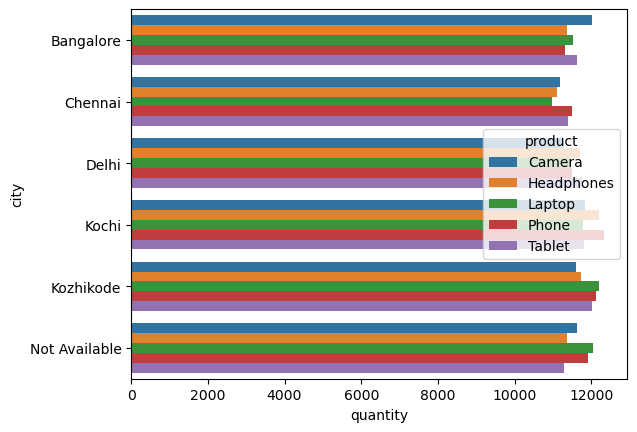

In [67]:
sns.barplot(data=sold_by_city, y='city', x='quantity', hue='product')
plt.show()

This bar chart shows the quantity of different products sold across various cities like Bangalore, Chennai, Delhi, Kochi, Kozhikode, and the “Not Available” category. From the chart, we can see that sales quantities are quite balanced across all cities and products, with only small differences between them. However, **"Kochi and Kozhikode show slightly higher sales quantities compared to other cities"**, indicating stronger product demand in these locations. Among the products, **"Phones, Tablets, and Laptops appear to have slightly higher sales in most cities"**, while Cameras and Headphones are slightly lower but still close in value. Overall, the chart suggests that **"all products are performing consistently across different cities"**, and **"there is no major gap in sales quantity between products or locations"**, showing stable and balanced sales performance.


In [68]:
join_2_columns.dtypes

transaction_id             int64
customer_id                int64
product                   object
quantity                   int64
price                    float64
date              datetime64[ns]
payment_method            object
discount                 float64
rating                   float64
remarks                   object
customer_name             object
city                      object
age                        int64
segment                   object
revenue                  float64
dtype: object

# Revenue By Products

In [69]:
product_rev = join_2_columns.groupby("product")["revenue"].sum().reset_index()
product_rev

,product,revenue
0,Camera,1.773733e+09
1,Headphones,1.755791e+09
2,Laptop,1.781450e+09
3,Phone,1.813250e+09
4,Tablet,1.780349e+09


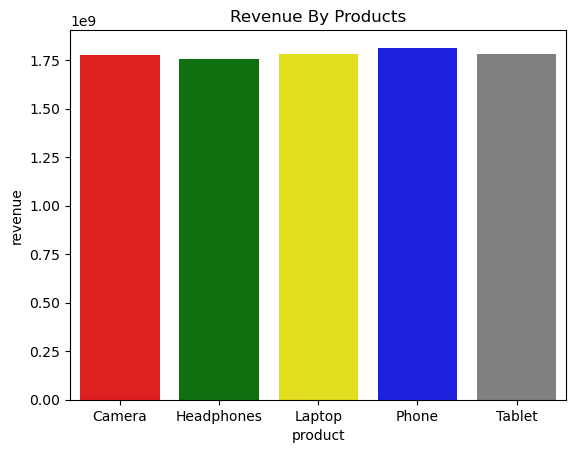

In [70]:
sns.barplot(data=product_rev,x='product',y='revenue',palette=["red","green","yellow","blue","grey"])
plt.title('Revenue By Products')
plt.show()

The bar chart titled **“Revenue By Products”** shows a comparison of total revenue generated by five product categories: Camera, Headphones, Laptop, Phone, and Tablet. All products have relatively similar revenue figures, indicating consistent performance across the categories, but there are slight differences. Among them, **Phones generate the highest revenue**, followed closely by **Laptops and Tablets**, while **Cameras and Headphones bring in slightly lower but still comparable amounts**. Overall, the chart suggests a balanced distribution of revenue with no extreme outliers, meaning each product contributes significantly to the total sales, with Phones having a small competitive edge.


# Revenue by City

In [71]:
rev_by_city =join_2_columns.groupby("city")["revenue"].sum().reset_index()
rev_by_city

,city,revenue
0,Bangalore,1.463903e+09
1,Chennai,1.423636e+09
2,Delhi,1.475599e+09
3,Kochi,1.525757e+09
4,Kozhikode,1.525724e+09
5,Not Available,1.489954e+09


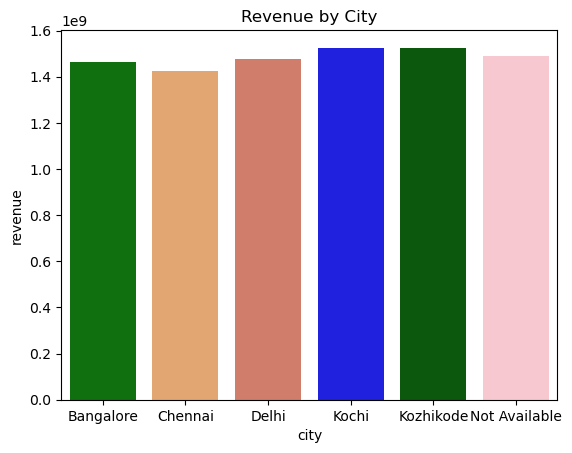

In [72]:
sns.barplot(data = rev_by_city,x="city",y="revenue",palette=["green","#F4A460","#E2725B","blue","#006400","PINK"])
plt.title("Revenue by City")
plt.show()

The above bar chart **“Revenue by City”** compares the total revenue generated across different cities: Bangalore, Chennai, Delhi, Kochi, Kozhikode, and a category labeled “Not Available.” The revenues across all cities are quite close to each other, indicating a fairly balanced market performance with no extreme gaps. Among them, **Kochi and Kozhikode show the highest revenue**, slightly leading the group, while **Chennai has the lowest revenue** compared to the others. Bangalore, Delhi, and the “Not Available” category fall in the middle range with similar values. Overall, the chart suggests that business performance is steady across locations, with only minor variations, and no single city dominating significantly.


# Distribution of payment methods

In [73]:
join_2_columns["payment_method"].value_counts()

payment_method
UPI            19601
Unavailable    19422
Card           19399
Cash           19360
Name: count, dtype: int64

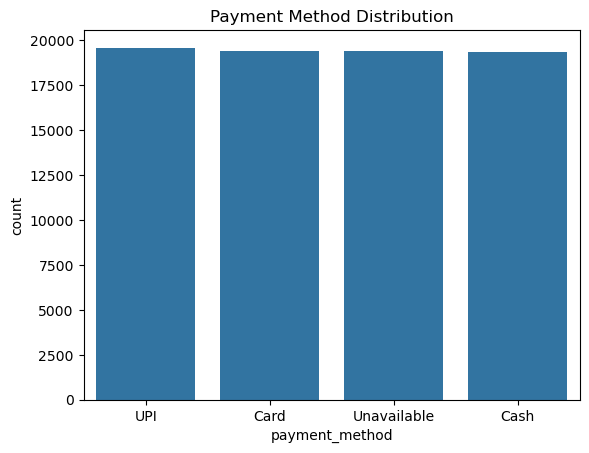

In [74]:
sns.countplot(data = join_2_columns,x="payment_method")
plt.title("Payment Method Distribution")
plt.show()

This chart shows the overall distribution of payment methods like UPI, Unavailable, Cash, and Card. From the chart, all the bars are almost the same height, which means each payment method is used nearly equally by customers. There is no big gap between any of them, but we can see that **"UPI is slightly higher than the others"**, while **"Cash and Unavailable are just a little lower"**, though the difference is very small. This tells us that customers are using all payment options in a balanced way, and **"no single payment method is dominating clearly"**, which shows a very even and stable payment pattern.


# Payment method by each city

In [75]:
payment_method_by_city = join_2_columns.groupby(["city","payment_method"])["payment_method"].count()
payment_method_by_city.head()

city       payment_method
Bangalore  Card              3202
           Cash              3315
           UPI               3357
           Unavailable       3150
Chennai    Card              3102
Name: payment_method, dtype: int64

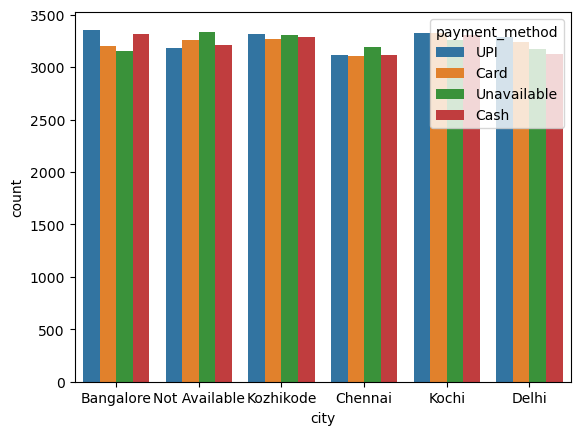

In [76]:
sns.countplot(data=join_2_columns, x="city", hue="payment_method")
plt.show()

This chart shows how different payment methods like UPI, Cash, Card, and Unavailable are used in different cities such as Bangalore, Delhi, Chennai, Kochi, Kozhikode, and also a “Not Available” category. If we look at the chart, all payment methods are used almost equally in every city, so there is no big difference or strong preference for just one method. Still, we can notice that **"UPI and Cash are used slightly more compared to others"**, which means people mostly prefer these two. Also, the total number of transactions in each city looks very similar, but **"Kochi and Kozhikode have a little higher activity"** while **"Chennai has slightly lower counts"** compared to others. Overall, this chart tells us that payment usage is very balanced across all cities, and **"no single payment method or city is dominating heavily"**.


# Each segments

In [77]:
segment_counts = join_2_columns['segment'].value_counts()
segment_counts

segment
Not Available    19570
Corporate        19463
Retail           19458
SME              19291
Name: count, dtype: int64

In [78]:
segment_counts = join_2_columns['segment'].value_counts(normalize=True)
segment_counts

segment
Not Available    0.251601
Corporate        0.250225
Retail           0.250161
SME              0.248014
Name: proportion, dtype: float64

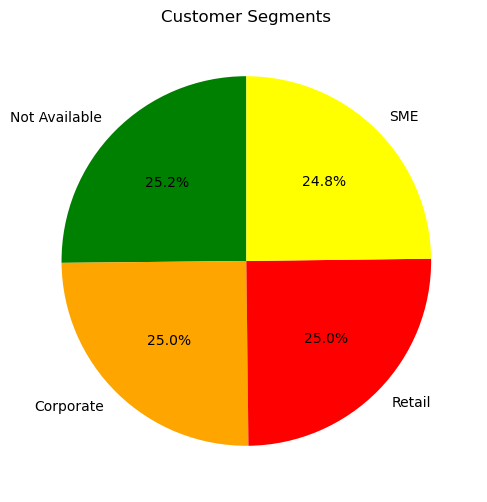

In [79]:


plt.figure(figsize=(6,6))
plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    colors=["green","orange","red","yellow"],
    startangle=90
)

plt.title("Customer Segments")
plt.show()

This pie chart shows how customers are distributed across different segments like SME, Retail, Corporate, and Not Available. From the chart, all the segments take almost equal portions of the pie, which means the customer base is very evenly divided. We can see that **"Not Available has a slightly higher share (25.2%)"**, while **"SME has a slightly lower share (24.8%)"**, but the difference is very small. Retail and Corporate both are exactly around 25%, making them equal contributors. Overall, this tells us that **"all customer segments contribute almost equally"**, and **"there is no single segment dominating the customer base"**, which shows a well-balanced distribution.


# Product Rating Distribution

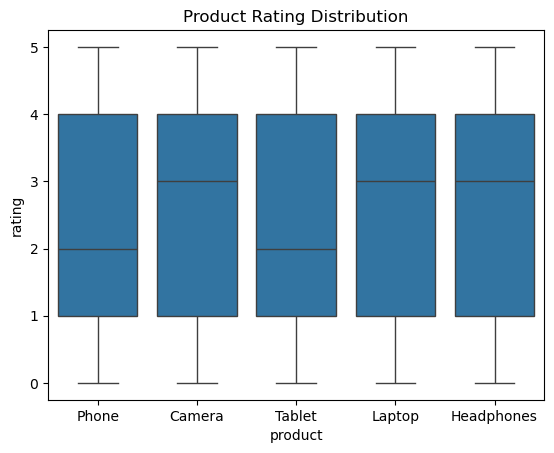

In [80]:
sns.boxplot(data = join_2_columns,x="product",y="rating")
plt.title("Product Rating Distribution")
plt.show()

This chart shows the distribution of ratings for different products like Camera, Laptop, Headphones, Tablet, and Phone. From the boxplot, we can see that ratings for all products range from 0 to 5, which means customers have given both low and high ratings across all categories. The middle line (median) for Camera, Laptop, and Headphones is around 3, showing average ratings, while **"Tablet and Phone have slightly lower median ratings around 2"**, meaning they are rated a bit lower compared to others. Also, the spread of the boxes is quite similar, which tells us that **"ratings are evenly spread and there is no extreme variation between products"**. Overall, this shows that most products receive moderate ratings, but **"Camera, Laptop, and Headphones perform slightly better in terms of customer satisfaction"** compared to Tablet and Phone.


# Discount vs Revenue

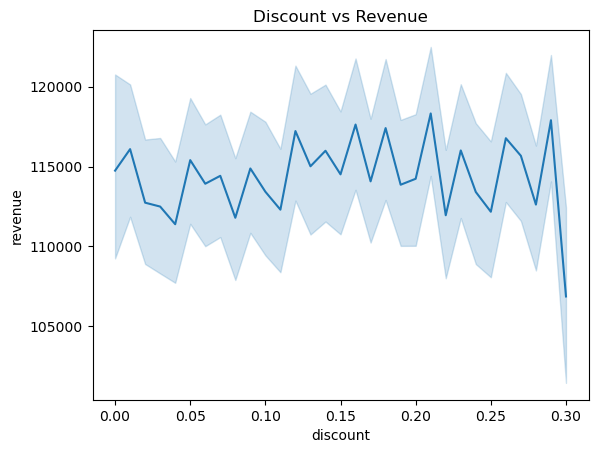

In [81]:
sns.lineplot(data=join_2_columns, x="discount", y="revenue")
plt.title("Discount vs Revenue")
plt.show()

This line plot shows how revenue changes with different discount values. The line goes slightly up and down across the graph, but there is no strong increasing or decreasing pattern. This means that **"revenue stays almost stable across different discount levels"**, with only small fluctuations. Even when the discount increases, revenue does not consistently go up or down. The shaded area around the line shows variation, but it is also fairly consistent throughout. Overall, this tells us that **"discount does not have a major impact on revenue"**, and **"the relationship between discount and revenue is weak and not clearly defined"**.


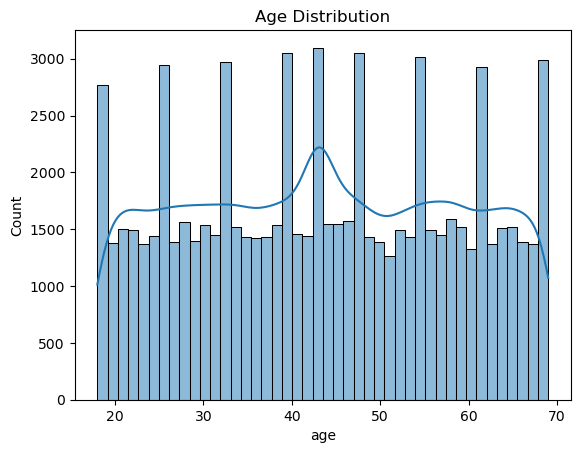

In [82]:
sns.histplot(data=join_2_columns, x="age", kde=True)
plt.title("Age Distribution")
plt.show()

This histogram shows the distribution of customer ages, along with a smooth KDE line to show the overall pattern. From the chart, we can see that ages are spread across a wide range, roughly from 18 to 70, and most age groups have a fairly similar number of people. There is no sharp peak, but we can notice a slight concentration around the middle ages. Overall, this means that **"customers are evenly distributed across different age groups"**, with a small rise around the mid-30s to mid-40s. Also, there are no extreme spikes or drops, which shows that **"there is no specific age group dominating heavily"**, and the data is quite balanced across all ages.


In [83]:
cols = ["quantity","price","discount","rating","age","revenue"]

for col in cols:
    join_2_columns[col] = pd.to_numeric(join_2_columns[col], errors='coerce')

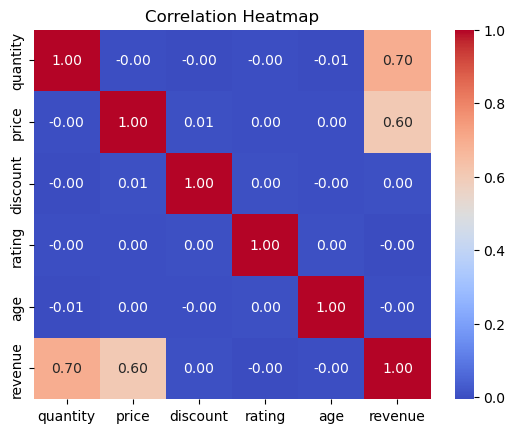

In [84]:
corr = join_2_columns[["quantity","price","discount","rating","age","revenue"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

This correlation heatmap shows how different variables like quantity, price, discount, rating, age, and revenue are related to each other. From the chart, we can clearly see that **"quantity has a strong positive correlation with revenue (0.70)"**, which means when quantity increases, revenue also increases significantly. Similarly, **"price also has a good positive correlation with revenue (0.60)"**, so higher prices also contribute to higher revenue. On the other hand, **"discount, rating, and age have almost zero correlation with revenue"**, which means they do not have a strong impact on revenue in this dataset. Also, most other relationships between variables are very close to zero, showing no strong connection between them. Overall, this heatmap tells us that **"revenue mainly depends on quantity and price"**, while other factors like discount, rating, and age do not influence it much.


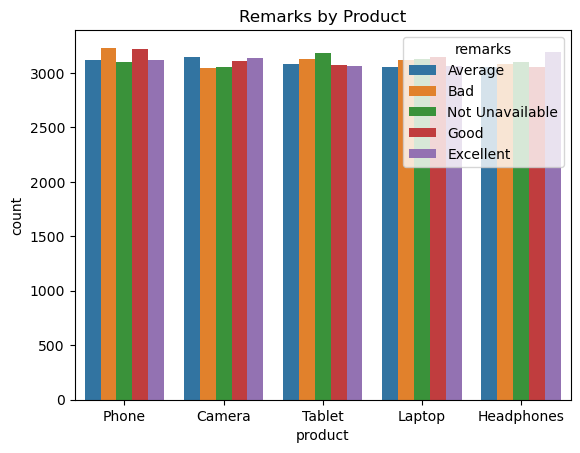

In [85]:
sns.countplot(data=join_2_columns, x="product", hue="remarks")
plt.title("Remarks by Product")
plt.xticks(rotation=360)
plt.show()

This chart shows how different types of customer remarks (Bad, Average, Good, Excellent, and Not Available) are distributed across products like Camera, Laptop, Headphones, Tablet, and Phone. From the chart, all the bars are very close in height, which means each type of remark is given almost equally for all products. There is no big difference between products in terms of feedback. Still, we can notice that **"Good and Excellent remarks are slightly higher in most products"**, which shows a generally positive customer response. At the same time, **"Bad and Average remarks are also present in similar numbers"**, meaning feedback is quite balanced and not extremely positive or negative. Overall, this tells us that **"customer opinions are evenly distributed across all products"**, and **"no single product stands out as having much better or worse reviews"**.


# Top Customers

In [86]:
top_customers = (
    join_2_columns.groupby("customer_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head()
)

print(top_customers)

customer_name
Cust_14674    1848819.06
Cust_15666    1814752.82
Cust_11225    1787438.85
Cust_5272     1757877.50
Cust_7219     1746190.95
Name: revenue, dtype: float64


This output shows the top 5 customers based on the total revenue they have generated. From the list, we can see that **"Cust_14674 is the highest contributing customer"** with the maximum revenue, followed by **"Cust_15666 and Cust_11225"** who also contribute significantly. The remaining customers like Cust_5272 and Cust_7219 are slightly lower but still among the top contributors. The difference between them is not extremely large, which means all these top customers are contributing in a fairly close range. Overall, this tells us that **"a small group of customers is generating a high portion of revenue"**, and these customers are very important for the business.


# Best product from each city

In [87]:
best_city_product = (
    join_2_columns.groupby(["city","product"])["revenue"]
    .sum()
    .reset_index()
)

best_city_product

,city,product,revenue
0,Bangalore,Camera,3.045470e+08
1,Bangalore,Headphones,2.876767e+08
2,Bangalore,Laptop,2.889844e+08
3,Bangalore,Phone,2.883678e+08
4,Bangalore,Tablet,2.943267e+08
5,Chennai,Camera,2.825665e+08
6,Chennai,Headphones,2.816891e+08
7,Chennai,Laptop,2.775908e+08
8,Chennai,Phone,2.969309e+08
9,Chennai,Tablet,2.848587e+08


This table shows the total revenue generated by each product in different cities. From the data, we can see that revenue values are quite similar across all city–product combinations, which means performance is fairly balanced. Still, some small differences are visible. For example, **"Phones generate the highest revenue in most cities like Kochi, Delhi, and Kozhikode"**, showing they are the top-performing product overall. Also, **"Kochi and Kozhikode slightly stand out with higher revenue values compared to other cities"**, indicating stronger sales in these locations. On the other hand, products like Headphones and Laptops show slightly lower values in some cities, but the difference is not very large. Overall, this tells us that **"all products perform consistently across cities"**, with **"Phones being the most revenue-generating product and Kochi/Kozhikode being slightly stronger markets"**.


## 📊 **Sales & Customer Insights Analysis – Summary Report**

This analysis provides a complete overview of sales performance, customer behavior, and key business factors across products, cities, and customer segments. From the product revenue analysis, all products contribute almost equally, showing a balanced portfolio, but **"Phones slightly lead in revenue generation"**, making them the top-performing category. Across cities, revenue distribution is also very consistent, with **"Kochi and Kozhikode performing slightly better than others"**, while no city shows a major drop in performance.

When analyzing payment methods, usage is evenly spread across UPI, Cash, Card, and other methods, indicating flexible customer preferences. However, **"UPI and Cash are used slightly more frequently"**, showing a mild preference for these methods. Similarly, customer segmentation shows a very balanced distribution, where **"Retail, SME, Corporate, and other segments contribute almost equally"**, meaning the business is not dependent on a single customer group.

Looking at customer feedback, product ratings are generally moderate, with most products having average ratings around the mid-level. Still, **"Camera, Laptop, and Headphones have slightly better ratings compared to Phone and Tablet"**, indicating relatively higher satisfaction. The remarks analysis also supports this, showing that feedback is evenly distributed, but **"Good and Excellent remarks are slightly more common"**, reflecting an overall positive customer experience.

From the relationship analysis, the correlation heatmap clearly shows that **"Revenue is strongly influenced by quantity (0.70) and price (0.60)"**, making them the key drivers of sales. On the other hand, **"discount, age, and rating have little to no impact on revenue"**, which is further supported by the discount vs revenue analysis where no clear trend is observed. This indicates that increasing discounts alone does not guarantee higher revenue.

Customer analysis reveals that **"a small group of top customers contributes significantly to total revenue"**, highlighting the importance of retaining high-value customers. Additionally, the age distribution shows that customers are spread across a wide range, with **"no single age group dominating heavily"**, indicating a diverse customer base.

Overall, this analysis shows that the business is stable and well-balanced across products, cities, and customer segments. The key insights highlight that **"revenue growth is mainly driven by quantity and price rather than discounts"**, and **"maintaining strong customer relationships and focusing on high-performing products like Phones can further improve business performance"**.
